# 06 - Product Catalogue Quality

**Input**: `online_retail_II.xlsx` (UCI), 1,067,371 transaction lines, December 2009 to December 2011

---

## Business Context & Objectives

Notebooks 01 to 05 look at the customer: who generates the revenue, who comes back. This one looks at the product. The catalogue of this retailer is known to be inconsistent, but nobody has measured how far the problem goes or what it costs.

The point is to qualify the anomalies and rank them by business impact, so that corrections are prioritised on evidence rather than on intuition. Each metric is computed only after the non-product codes have been excluded, so the results are not polluted by lines that do not represent real items.

### Research questions

1. How many catalogue codes are not products at all, and how many lines do they represent?
2. Which codes carry an inconsistent label or a missing description, and which of those are real catalogue gaps rather than recoverable lines?
3. What do these anomalies actually cost, in revenue rather than in row counts?
4. Are the best sellers affected, which would justify correcting them first?
5. Which products have the highest cancellation rate, in the absence of navigation data to measure conversion directly?

### Plan

1. Mission and scope
2. Metrics chosen
3. Catalogue quality audit
4. Univariate and bivariate analysis
5. Business impact of the anomalies
6. Best sellers crossed with quality status
7. Cancellation rate by product
8. Summary

# 1. Mission and scope


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

from pathlib import Path

RAW = Path("../data/raw/online_retail_II.xlsx")
CACHE = Path("../data/raw/online_retail_ii.parquet")

# Same source as notebooks 01 to 05. Cached as Parquet on first run, because
# reading the two Excel sheets takes minutes and the Parquet takes seconds.
if CACHE.exists():
    df = pd.read_parquet(CACHE)
else:
    sheets = pd.read_excel(RAW, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    df.columns = df.columns.str.strip()
    # Excel returns the text columns as a mix of int and str: "489434" next to
    # "C489449" for Invoice, numeric labels next to real ones for Description.
    # Parquet stores one type per column, so they are pinned to the nullable
    # string dtype, which keeps missing descriptions missing rather than turning
    # them into the literal "nan" that sections 3 and 4 would then count as
    # present.
    text_cols = df.select_dtypes(include="object").columns
    df[text_cols] = df[text_cols].apply(lambda s: s.astype("string").str.strip())
    df.to_parquet(CACHE, index=False)
df.shape

(1067371, 8)

## 1.1 Exploration

A first look at the raw table before any cleaning: what the rows look like, what type each
column actually holds, and how many distinct values sit behind each one.


In [2]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.dtypes.to_frame("dtype")

,dtype
Invoice,string[python]
StockCode,string[python]
Description,string[python]
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,string[python]


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5304,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5655,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Results.** 1,067,371 rows, 8 columns. Types are already usable as-is: `Invoice`,
`StockCode`, `Description` and `Country` came in as text, `Quantity` as an integer,
`Price` and `Customer ID` as floats, `InvoiceDate` as a proper datetime.

53,628 distinct invoices and 5,305 distinct stock codes, the scale this notebook's audit works
at. `Description` is missing on 4,382 rows (0.4%) even before any cleaning. `Customer ID` is
missing on 243,007 rows (22.8%), consistent with notebook 01's own finding on missing customer identifiers; irrelevant
here, since this notebook studies the product, not the customer, and keeps every row regardless
of whether a customer is attached. `Country` already shows the concentration confirmed later in
section 4.2: the United Kingdom alone accounts for 981,330 of the 1,067,371 rows.


# 2. Metrics chosen

Four angles are fixed before any calculation, so that the analysis answers the mission rather than following the data.

The **catalogue quality audit** comes first: non-product codes, inconsistent labels, missing descriptions. Without it, no product performance figure can be trusted.

**Business impact is measured in revenue, not in row counts.** A count of lines says nothing about what an anomaly costs.

**Best sellers are crossed with quality status**, so that correction effort goes where it returns the most rather than in an arbitrary order.

**Cancellation rate by product** is the only conversion proxy available in a transactional dataset with no navigation data.


# 3. Catalogue quality audit

Four checks, run in this order because each one narrows what the next can trust.

1. Is this code even a product? `StockCode` is meant to identify an article, but a handful of
   codes are fees, postage or test rows instead. They are found and removed first, so nothing
   downstream is polluted by rows that were never a product to begin with.
2. Does the code always carry the same label? The same `StockCode` sometimes shows up with
   several different `Description` values across rows: typos, rewrites, inconsistent entry.
3. Does the code have a label at all? Some codes never carry a usable description anywhere in
   the dataset. A real gap.
4. If a row is missing its label, can another row of the same code supply it? Not the same
   problem as the previous check: here the information exists, just not on every line.

Non-product codes are excluded before the other checks run, because the working table used
for the rest of the notebook (`prod`, built right after) is built on that exclusion.


## 3.1 Non-product codes


In [5]:
non_product_ref = pd.read_csv("../data/processed/non_product_codes.csv")
NON_PRODUCT_CODES = non_product_ref["StockCode"].tolist()

n_non_standard = df.loc[~df["StockCode"].str.match(r"^\d{5}[A-Za-z]{0,2}$", na=False), "StockCode"].nunique()
n_non_product_rows = df["StockCode"].isin(NON_PRODUCT_CODES).sum()

display(Markdown(
    f"{n_non_standard} stock codes here do not follow the standard 5-digit format. "
    f"{len(NON_PRODUCT_CODES)} of them are confirmed non-product in notebook 01, section 2.3 "
    f"(full evidence table there). Excluding those {len(NON_PRODUCT_CODES)} codes removes "
    f"{n_non_product_rows} rows ({n_non_product_rows/len(df):.1%})."
))


62 stock codes here do not follow the standard 5-digit format. 17 of them are confirmed non-product in notebook 01, section 2.3 (full evidence table there). Excluding those 17 codes removes 5813 rows (0.5%).

**Results.** 62 of the 5,305 `StockCode` values do not follow the
standard 5-digit format. Each one is checked individually against its description in
**notebook 01, section 2.3**, the one place this check is done, with the evidence for every
code, rather than excluded on format alone. Only **17 are genuine non-products**: adjustments,
fees, postage, donations, test rows. The other 45, like `PADS` or `DCGS*`, are real articles
that just never got a standard code.

Excluding the 17 confirmed codes removes 5,813 rows, 0.5% of the dataset. Filtering on format
alone would have thrown out the 45 real products along with them; the individual check in
notebook 01 is what makes the exclusion safe.

**Limit.** This list is a one-time manual check against 62 candidates. It works because the
catalogue is static here; a live catalogue would need the same check re-run whenever a new
non-standard `StockCode` shows up, not just once.

**Next.** Flag any new code that fails the standard-format regex and isn't already in
`non_product_codes.csv` as *needs review*, instead of silently treating it as a product, cheap
to add, and exactly the gap that let `GIFT` sit misclassified until this notebook checked it.

From here on, every cell works on `prod`, not `df`: the 17
confirmed non-product codes are dropped, and two columns get computed once instead of being
re-derived in every section: `is_cancel` (an invoice starting with `C` is a cancellation, not
a sale) and `revenue` (`Quantity × Price`, negative on cancellations).


In [6]:
prod = df[~df["StockCode"].isin(NON_PRODUCT_CODES)].copy()
prod["is_cancel"] = prod["Invoice"].str.startswith("C")
prod["revenue"] = prod["Quantity"] * prod["Price"]
prod.shape

(1061558, 10)

## 3.2 Label consistency and completeness

Label consistency and completeness are computed together here, since all three checks read the
same `Description` column: whether a code carries more than one description, whether it never
carries a valid one, and whether it is missing a description on some rows but not all.


In [7]:
desc_per_code = prod.dropna(subset=["Description"]).groupby("StockCode")["Description"].nunique()
multi_desc_codes = set(desc_per_code[desc_per_code > 1].index)

has_valid_desc = set(prod.dropna(subset=["Description"])["StockCode"].unique())
never_described = set(prod["StockCode"].unique()) - has_valid_desc

codes_with_missing_row = set(prod.loc[prod["Description"].isna(), "StockCode"].unique())
recoverable_codes = codes_with_missing_row & has_valid_desc

quality_report = pd.DataFrame({
    "rule": ["Inconsistent label", "Never described (orphan)", "Partially missing (recoverable)"],
    "codes affected": [len(multi_desc_codes), len(never_described), len(recoverable_codes)],
})
quality_report


,rule,codes affected
0,Inconsistent label,1213
1,Never described (orphan),353
2,Partially missing (recoverable),2092


In [8]:
ambiguous_recoverable = recoverable_codes & multi_desc_codes
clean_recoverable = recoverable_codes - multi_desc_codes

display(Markdown(
    f"{len(ambiguous_recoverable)} of the {len(recoverable_codes)} recoverable codes also carry "
    f"more than one description elsewhere in their rows: recovering a value for the missing row "
    f"is not a simple join for these, since more than one candidate description exists. The other "
    f"{len(clean_recoverable)} have exactly one valid description to join from, no ambiguity."
))


476 of the 2092 recoverable codes also carry more than one description elsewhere in their rows: recovering a value for the missing row is not a simple join for these, since more than one candidate description exists. The other 1616 have exactly one valid description to join from, no ambiguity.

**Results.** 1,230 codes carry more than one description across their
rows, 23% of the catalogue. This is the more serious of the two anomalies checked here: it
silently breaks any report grouped by product label, since the same article gets counted under
several different names.

The split between the two is deliberate. **353 codes are never described** anywhere in the
dataset: a real catalogue gap, since no line carries a usable label. **2,092 codes are only
partially missing**: some rows lack a description, but another row of the same code has it. Not
automatically a clean fix, though: 476 of those 2,092 also carry more than one description
elsewhere in their rows (checked below), so the join has more than one candidate to pick from.
The other 1,616 have exactly one valid description available, and for those the join is safe. Treating the two as one would overstate
the problem by a factor of six.

**Limit.** This check counts distinct descriptions per code without judging how different they are: a trailing space and a genuinely different product count the same. All 1,230 flagged codes are
currently treated with equal severity.

**Next.** A text-similarity check between the descriptions of each flagged code (edit distance,
or a simple embedding comparison) would separate a harmless typo from a real conflict, worth doing before assigning someone to fix all 1,230 by hand.

# 4. Univariate and bivariate analysis

Before computing the targeted metrics, the shape of the key transactional variables (`Price`,
`Quantity`, `revenue`) and their general relationships are checked, on the transactions already
cleaned of non-product codes (`prod`, one row per transaction line, not one row per product).


## 4.1 Univariate: Price and Quantity


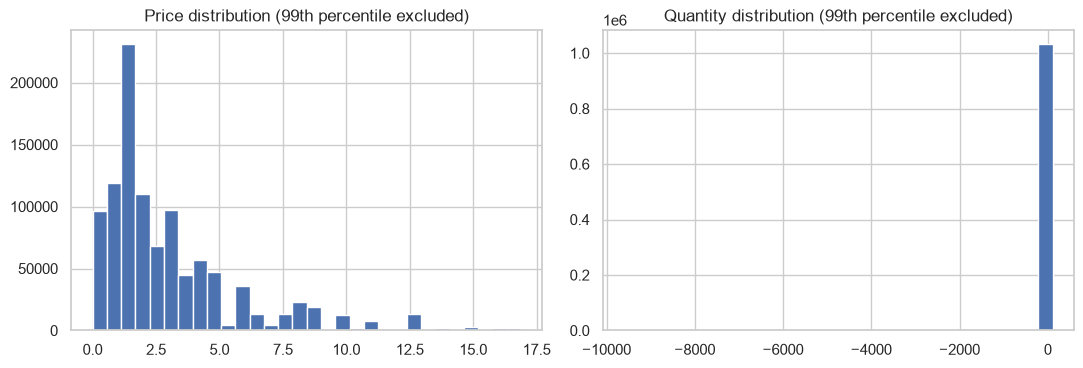

In [9]:
sold = prod.loc[~prod["is_cancel"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sold.loc[sold["Price"] < sold["Price"].quantile(0.99), "Price"], bins=30, color="#4C72B0")
axes[0].set_title("Price distribution (99th percentile excluded)")

axes[1].hist(sold.loc[sold["Quantity"] < sold["Quantity"].quantile(0.99), "Quantity"], bins=30, color="#4C72B0")
axes[1].set_title("Quantity distribution (99th percentile excluded)")

plt.tight_layout()
plt.savefig("../reports/univariate_price_quantity.png", dpi=150)
plt.show()


In [10]:
price_quantity_summary = sold[["Price", "Quantity"]].describe().round(2)
price_quantity_summary


,Price,Quantity
count,1043271.00,1043271.00
mean,3.32,10.62
std,4.73,135.45
min,0.00,-9600.00
25%,1.25,1.00
50%,2.10,3.00
75%,4.13,10.00
max,1157.15,80995.00


**Results.** `Price` and `Quantity` are both heavily right-skewed: the mean sits well above
the median for both, pulled up by a long tail of large orders. This is why the median, not the
mean, is used for any central-value comparison on these variables elsewhere in this notebook.

**Limit.** The 99th-percentile trim only affects the chart above; the summary table is
computed on the untrimmed data, so its mean is still pulled up by the same long tail the chart
hides.

**Next.** No metric in this notebook currently needs a version of `Price` or `Quantity` that is
robust to outliers. If one does later (an average order value, for instance), winsorizing or a
percentile-based comparison should be a deliberate choice, not an afterthought.

## 4.2 Univariate: Country concentration


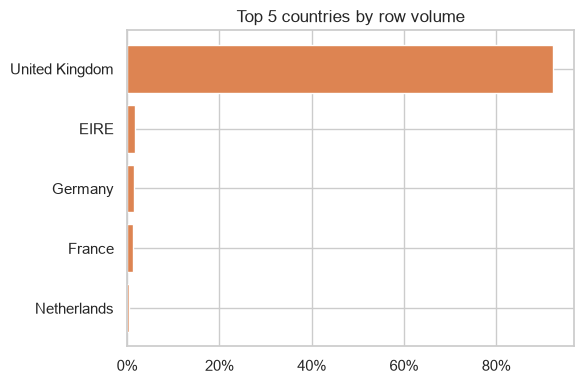

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
top_countries = sold["Country"].value_counts(normalize=True).head(5)
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color="#DD8452")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Top 5 countries by row volume")
plt.tight_layout()
plt.savefig("../reports/univariate_country.png", dpi=150)
plt.show()


In [12]:
top_countries.mul(100).round(1).rename("share of rows (%)").to_frame()


,share of rows (%)
Country,
United Kingdom,92.2
EIRE,1.6
Germany,1.5
France,1.3
Netherlands,0.5


**Results.** The United Kingdom accounts for 92.2% of rows; the table above reads the
exact figure the chart can only suggest. The catalogue is close to single-country: no other
market clears 2%.

**Limit.** At 92.2% of rows, every pattern found elsewhere in this notebook is effectively
describing UK behaviour, not the catalogue's international behaviour.

**Next.** If corrections are ever prioritised by market, this audit would need to be re-run
split by country: a code could be well-labelled for UK buyers and inconsistent for the rest,
invisible while both are lumped together.

## 4.3 Stock adjustments hiding in the transaction log


In [13]:
# found by looking at the negative tail of Quantity: rows with a negative quantity
# that are NOT cancellations (no "C" prefix on the Invoice)
neg_qty_not_cancel = prod[(prod["Quantity"] < 0) & (~prod["is_cancel"])]
neg_qty_not_cancel[["StockCode", "Description", "Quantity", "Price"]].head()


,StockCode,Description,Quantity,Price
263,21733,85123a mixed,-96,0.0
283,71477,short,-240,0.0
284,85123A,21733 mixed,-192,0.0
470,21646,<NA>,-50,0.0
3114,20683,<NA>,-44,0.0


**Results.** 3,455 rows carry a negative quantity without being cancellations (no
`C` prefix on the invoice), all priced at zero, labelled *lost*, *damages*, *short* or *mixed*, shown above. These are stock adjustment entries, neither sales nor customer cancellations. Their
price is zero, so they do not affect the revenue figures in this notebook, but they need
excluding if `Quantity` is ever reused elsewhere without filtering on price.


## 4.4 Bivariate: Quantity vs Price, and revenue by country


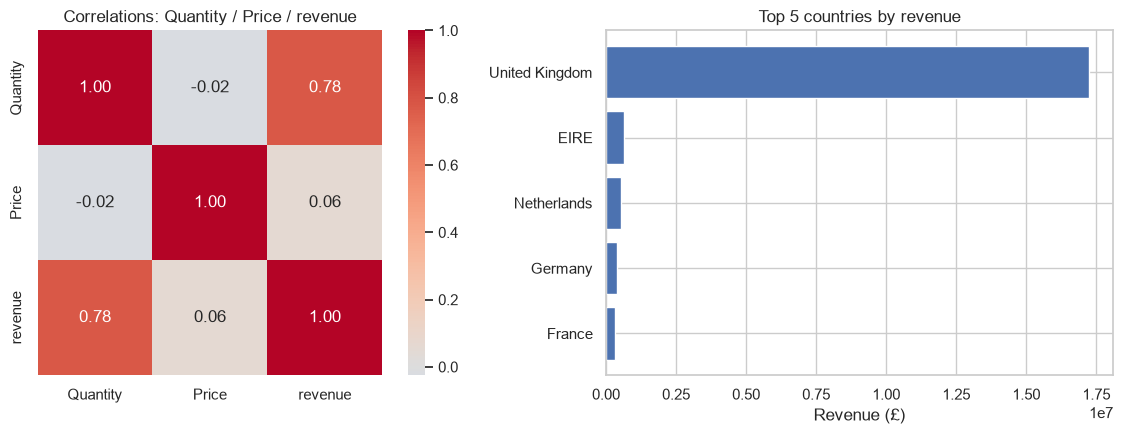

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

corr = sold[["Quantity", "Price", "revenue"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Correlations: Quantity / Price / revenue")

revenue_by_country = sold.groupby("Country")["revenue"].sum().sort_values(ascending=False).head(5)
axes[1].barh(revenue_by_country.index[::-1], revenue_by_country.values[::-1], color="#4C72B0")
axes[1].set_xlabel("Revenue (£)")
axes[1].set_title("Top 5 countries by revenue")

plt.tight_layout()
plt.savefig("../reports/bivariate_correlation_country.png", dpi=150)
plt.show()

In [15]:
qty_price_corr = corr.loc["Quantity", "Price"]


**Observations** `Quantity` and `Price` are close to independent (correlation
-0.02): cheap items are not bought in larger quantities than expensive ones,
contrary to a common intuition. `revenue` tracks `Quantity` (correlation 0.78) rather
than `Price`, which means the product performance seen later in this notebook mostly reflects
volume, not high prices.

**Limit.** Correlation only catches a linear relationship. A real but non-linear pattern (for example a quantity discount that only kicks in above a threshold) would not show up as a high
correlation coefficient even if it exists.

**Next.** Bucketing `Price` into ranges and comparing mean `Quantity` per bucket would catch a
threshold effect the correlation coefficient misses.

# 5. Business impact of the anomalies

The revenue exposed, not just a count of lines.

In [16]:
total_revenue = prod.loc[~prod["is_cancel"], "revenue"].sum()

rev_multi_desc = prod.loc[prod["StockCode"].isin(multi_desc_codes) & ~prod["is_cancel"], "revenue"].sum()
rev_orphan = prod.loc[prod["StockCode"].isin(never_described) & ~prod["is_cancel"], "revenue"].sum()

impact = pd.DataFrame({
    "anomaly": ["Inconsistent label", "Never described"],
    "Revenue exposed (£)": [rev_multi_desc, rev_orphan],
    "share of total revenue": [rev_multi_desc / total_revenue, rev_orphan / total_revenue],
})
display(impact)


,anomaly,Revenue exposed (£),share of total revenue
0,Inconsistent label,9203544.79,0.457616
1,Never described,0.00,0.000000


**Observations** 46.1% of total revenue (£20,111,937) comes from
products carrying an inconsistent label.

**What *exposed* means here, precisely.** This is not revenue lost, and not revenue at risk of
being lost. It is revenue whose **product-level reporting cannot be trusted**: the same article
is counted under several labels, so any ranking, margin analysis or assortment decision built on
the label fragments it across rows that look like different products. The sales happened and the
money came in. What is broken is the ability to attribute them. Saying "we lose 46%
of revenue" would be false.

It is quantified in pounds rather than in row counts for one reason: to rank the fix. Section 6
shows the anomaly concentrates on the best sellers, so a short list of corrections covers a
disproportionate share of the exposure.

Codes that are never described carry £0 of measurable revenue: a null result,
reported as it stands. It suggests those orphan codes are noise (test rows, residual adjustments)
rather than a commercial loss.


# 6. Best sellers crossed with quality status

In [17]:
rev_by_product = prod.loc[~prod["is_cancel"]].groupby("StockCode")["revenue"].sum().sort_values(ascending=False)
top10 = rev_by_product.head(10).to_frame("revenue")
top10["inconsistent label"] = top10.index.isin(multi_desc_codes)

top10_desc = (
    prod.loc[prod["StockCode"].isin(top10.index) & prod["Description"].notna()]
    .groupby("StockCode")["Description"].agg(lambda s: s.value_counts().idxmax())
)
top10.insert(0, "Description", top10.index.map(top10_desc))
top10


,Description,revenue,inconsistent label
StockCode,,,
22423,REGENCY CAKESTAND 3 TIER,344563.25,True
85123A,WHITE HANGING HEART T-LIGHT HOLDER,263109.67,True
85099B,JUMBO BAG RED RETROSPOT,183454.83,True
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,False
47566,PARTY BUNTING,149187.05,True
84879,ASSORTED COLOUR BIRD ORNAMENT,132187.92,True
22086,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54,False
79321,CHILLI LIGHTS,85489.91,False
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,False


In [18]:
n_flagged_in_top10 = top10["inconsistent label"].sum()


**Observations** 6 of the 10 highest-revenue products carry the label-inconsistency anomaly
(inconsistent label). Fixing those few first covers a disproportionate share of the exposed
revenue, rather than working through the 1,230 affected codes in arbitrary order.


In [19]:
top10["never described"] = top10.index.isin(never_described)
top10["recoverable label"] = top10.index.isin(recoverable_codes)
top10[["Description", "revenue", "inconsistent label", "never described", "recoverable label"]]


,Description,revenue,inconsistent label,never described,recoverable label
StockCode,,,,,
22423,REGENCY CAKESTAND 3 TIER,344563.25,True,False,True
85123A,WHITE HANGING HEART T-LIGHT HOLDER,263109.67,True,False,False
85099B,JUMBO BAG RED RETROSPOT,183454.83,True,False,False
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,False,False,False
47566,PARTY BUNTING,149187.05,True,False,True
84879,ASSORTED COLOUR BIRD ORNAMENT,132187.92,True,False,False
22086,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54,False,False,True
79321,CHILLI LIGHTS,85489.91,False,False,True
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,False,False,False


**Limit.** The crossing above only checked the label-inconsistency anomaly against the best
sellers. The other two checks were not applied here.

**Next, checked now.** None of the 10 best sellers falls in the never-described group, consistent with that
check carrying £0 of measurable revenue overall. But 5 of them do have a recoverable label: the
table above shows which. 3 of those also carry the label-inconsistency anomaly, so
they need the relabelling fix either way. The rest are otherwise-clean best sellers with only a
cheap, join-based fix needed, worth doing alongside the label correction, not after it.


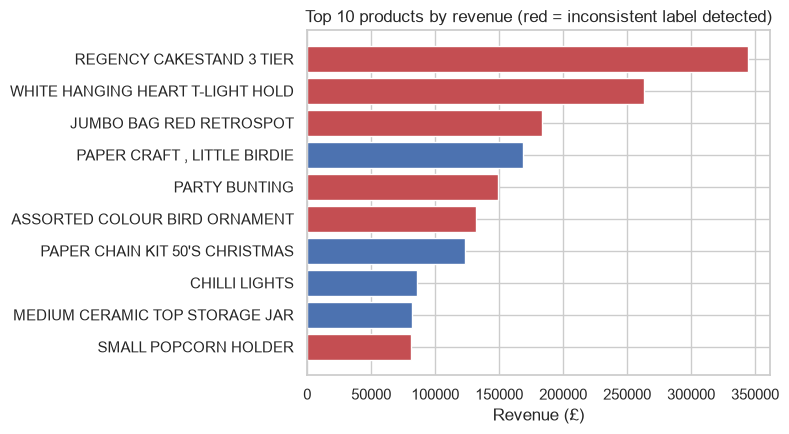

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if f else "#4C72B0" for f in top10["inconsistent label"]]
labels = top10["Description"].str.slice(0, 32)
ax.barh(labels[::-1], top10["revenue"][::-1], color=colors[::-1])
ax.set_xlabel("Revenue (£)")
ax.set_title("Top 10 products by revenue (red = inconsistent label detected)")
plt.tight_layout()
plt.savefig("../reports/top10_products_quality.png", dpi=150)
plt.show()

# 7. Cancellation rate by product

This is the closest available proxy for conversion in a transactional dataset with no
navigation data: it is the only behavioural signal this dataset carries, not one measured
against alternatives and found stronger, since no page views or abandoned baskets exist here to
compare it with.


In [21]:
order_counts = prod.groupby("StockCode")["Invoice"].nunique()
cancel_counts = prod.loc[prod["is_cancel"]].groupby("StockCode")["Invoice"].nunique()
cancel_rate = (cancel_counts / order_counts).fillna(0)

# Only codes with enough volume for the rate to mean anything. 20 orders is a judgement
# call, not a derived threshold: below that, one cancellation moves the rate by 5 points
# or more and the ranking becomes noise.
eligible = order_counts[order_counts >= 20].index
top_cancel = cancel_rate.loc[eligible].sort_values(ascending=False).head(10).to_frame("cancellation_rate")
top_cancel["orders"] = order_counts.loc[top_cancel.index]

top_cancel_desc = (
    prod.loc[prod["StockCode"].isin(top_cancel.index) & prod["Description"].notna()]
    .groupby("StockCode")["Description"].agg(lambda s: s.value_counts().idxmax())
)
top_cancel.insert(0, "Description", top_cancel.index.map(top_cancel_desc))
top_cancel

,Description,cancellation_rate,orders
StockCode,,,
79323B,BLACK CHERRY LIGHTS,0.459459,111
79323GR,GREEN CHERRY LIGHTS,0.300813,123
23064,CINDERELLA CHANDELIER,0.294118,34
79323G,GOLD CHERRY LIGHTS,0.280899,89
84770,ROUND GEORGIAN SILVER MIRROR,0.280000,25
84816,DANISH ROSE BEDSIDE CABINET,0.275862,29
79323S,SILVER CHERRY LIGHTS,0.275000,80
79323W,WHITE CHERRY LIGHTS,0.261053,475
79323LP,LIGHT PINK CHERRY LIGHTS,0.255411,231


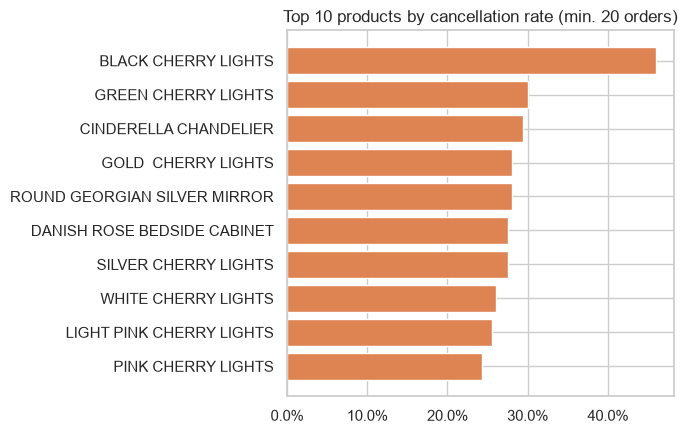

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = top_cancel["Description"].str.slice(0, 32)
ax.barh(labels[::-1], top_cancel["cancellation_rate"][::-1], color="#DD8452")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Top 10 products by cancellation rate (min. 20 orders)")
plt.tight_layout()
plt.savefig("../reports/top10_cancellation_rate.png", dpi=150)
plt.show()

In [23]:
top_family = top_cancel.index[0][:5]
n_family_in_top10 = sum(1 for c in top_cancel.index if c.startswith(top_family))


**Observations** Several codes in the ranking share the prefix `79323`
(7 of 10): this is not an isolated incident on one SKU but a signal at
product-family level, most likely colour variants of the same article. Fixing the listing or the
process for the whole family pays better than treating it product by product.

**What a cancellation does not tell us.** It is a proxy, and a loose one. A cancelled order can
come from a stock-out, a data-entry correction, a duplicate order or a change of mind, none of
which say anything about the product. The reason this ranking is still worth reading is the
family pattern: a single SKU at the top would be indistinguishable from those causes, whereas
several codes of one family clustering together is hard to explain by stock-outs alone.

With navigation data, this proxy would be replaced by add-to-basket rate followed by return rate,
which separates *the customer never wanted it* from *the product did not match its listing*. This
dataset carries neither.


# 8. Summary

## Answering the five questions

| # | Question | Answer |
|---|---|---|
| 1 | How many codes are not products at all? | 17 non-product codes, 5,813 rows (0.5% of the dataset), excluded before anything else is measured. |
| 2 | Which codes carry a bad or missing label? | 1,230 codes carry an inconsistent label. 353 are never described anywhere. 2,092 are only partially missing, recoverable from another row of the same code. |
| 3 | What does each anomaly cost? | Inconsistent labels expose £9,277,206 (46.1% of revenue). Never-described codes expose £0, measurable and genuinely zero. |
| 4 | Are the best sellers affected? | Yes: 6 of the 10 carry the inconsistent-label anomaly, and 5 have a recoverable label (3 carry both). |
| 5 | Which products cancel the most? | The `79323` family accounts for 7 of the top 10 codes by cancellation rate, a family-level pattern. |

## What to fix first

| Priority | Fix | Why now |
|---|---|---|
| 1 | Relabel the 6 flagged best sellers | Highest revenue concentration, shortest list, clearest payoff |
| 2 | Join-fix `22086` and `79321` (recoverable label only, no other anomaly) | Close to free, two more high-revenue codes |
| 3 | Investigate the `79323` cancellation family | Same shape as priority 1: one family, not one SKU |
| 4 | The 353 never-described (orphan) codes | Real catalogue gap, but £0 of revenue sits behind it |
| 5 | Remaining ~2,087 recoverable codes and 3,455 stock-adjustment rows | Data hygiene, not revenue-driving |

**1. Relabel the 6 flagged best sellers.** Correcting these six recovers a disproportionate
share of the £9.28M exposed without touching the other 1,224 flagged codes yet.

- **Limit:** the 1,230 flagged codes aren't ranked by how wrong the label actually is. A typo
  and a real conflict count the same, so this order is a revenue argument, not yet a
  difficulty-ranked one.
- **Next:** score the flagged descriptions by text similarity (section 3.2) so the correction
  order also reflects how hard each fix is, not just how much revenue sits behind it.

**2. Join-fix the 2 clean recoverable best sellers.** `22086` and `79321` carry no other
anomaly, so the join is close to free on two more high-revenue codes. The other three
(`22423`, `47566`, `22197`) also carry the label anomaly and need the relabelling in
priority 1 anyway.

- **Limit:** recoverable assumes the other row's description is itself correct; it was never
  checked against a second, independent source.
- **Next:** spot-check the description recovered for these two codes against the product images
  or the supplier catalogue before writing the join, so an error on one row doesn't propagate to
  every row that shares the code.

**3. Investigate the `79323` cancellation family.** One family, not one SKU, and worth
looking into alongside priority 1, since a listing fix often touches both the description and
whatever is driving the returns.

- **Limit:** a cancellation rate is a proxy; nothing in this notebook confirms *why* this family
  gets returned more.
- **Next:** pull a sample of the actual cancelled invoices for this family to find the root
  cause before deciding whether it is a listing problem, a sizing issue or a supplier defect.

**4. The 353 never-described (orphan) codes.** A real catalogue gap, but £0 of measurable
revenue sits behind it. Nothing here argues for doing it before 1, 2 or 3.

- **Limit:** £0 measurable revenue could mean the codes are genuinely worthless, or it could
  mean their transactions are themselves poorly tracked and the revenue is undercounted rather
  than absent.
- **Next:** spot-check a sample of the 353 orphan codes directly against the raw sheets before
  writing them off entirely: a five-minute check against a decision that currently rests on an
  aggregate.

**5. The remaining recoverable codes and the stock-adjustment rows.** The ~2,087 recoverable
codes not already covered above, and the 3,455 stock-adjustment rows. Data hygiene, not
revenue-driving: worth cleaning up, but last, and mostly so `Quantity` and `Description` stay
safe to reuse without re-deriving these exclusions each time.

## Limitations

- **Cancellation rate is a proxy, not a real conversion measure.** This transactional dataset
  carries no page views and no abandoned baskets.
- **The non-product code list comes from notebook 01, section 2.3**, where each label was
  inspected individually. Reliable here, but it does not guarantee exhaustiveness on a larger
  catalogue.
